# 🚗 Vehicle Loan Default — EDA
**Framework:** 5 Business Themes × Domain-First Questions  
**Data:** `../data/train.csv`  (233,154 สัญญา)

> คำถามแต่ละข้อเขียนสมมติฐานไว้ก่อน แล้วค่อยพิสูจน์ด้วย data

## ⚙️ Setup

In [2]:
import warnings, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

DATA_PATH = "../data/train.csv"
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.upper()

# ── parse age-string columns (e.g. "2yrs 3mon") → total months
def parse_months(s):
    if pd.isna(s): return np.nan
    y = re.search(r"(\d+)yrs", str(s))
    m = re.search(r"(\d+)mon", str(s))
    return int(y.group(1))*12 + int(m.group(1)) if y else np.nan

df["AVERAGE_ACCT_AGE_MON"]    = df["AVERAGE_ACCT_AGE"].apply(parse_months)
df["CREDIT_HISTORY_LEN_MON"]  = df["CREDIT_HISTORY_LENGTH"].apply(parse_months)

# ── compute age
df["DATE_OF_BIRTH"]  = pd.to_datetime(df["DATE_OF_BIRTH"],  dayfirst=True, errors="coerce")
df["DISBURSAL_DATE"] = pd.to_datetime(df["DISBURSAL_DATE"], dayfirst=True, errors="coerce")
df["AGE_AT_DISBURSAL"] = (df["DISBURSAL_DATE"] - df["DATE_OF_BIRTH"]).dt.days // 365

print(f"Shape: {df.shape}")
print(f"Default rate: {df['LOAN_DEFAULT'].mean():.2%}")
df.head(2)

Shape: (233154, 44)
Default rate: 21.71%


,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,...,SEC_INSTAL_AMT,NEW_ACCTS_IN_LAST_SIX_MONTHS,DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT,AVERAGE_ACCT_AGE_MON,CREDIT_HISTORY_LEN_MON,AGE_AT_DISBURSAL
0,420825,50578,58400,89.55,67,22807,45,1441,1984-01-01,Salaried,...,0,0,0,0yrs 0mon,0yrs 0mon,0,0,0,0,34
1,537409,47145,65550,73.23,67,22807,45,1502,1985-07-31,Self employed,...,0,0,1,1yrs 11mon,1yrs 11mon,0,1,23,23,33


## 🔍Data Overview

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 233154 entries, 0 to 233153
Data columns (total 56 columns):
 #   Column                               Non-Null Count   Dtype         
---  ------                               --------------   -----         
 0   UNIQUEID                             233154 non-null  int64         
 1   DISBURSED_AMOUNT                     233154 non-null  int64         
 2   ASSET_COST                           233154 non-null  int64         
 3   LTV                                  233154 non-null  float64       
 4   BRANCH_ID                            233154 non-null  int64         
 5   SUPPLIER_ID                          233154 non-null  int64         
 6   MANUFACTURER_ID                      233154 non-null  int64         
 7   CURRENT_PINCODE_ID                   233154 non-null  int64         
 8   DATE_OF_BIRTH                        233154 non-null  datetime64[us]
 9   EMPLOYMENT_TYPE                      225493 non-null  str           
 10  DISBURS

In [28]:
df.describe()

,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,DISBURSAL_DATE,...,AVERAGE_ACCT_AGE_MON,CREDIT_HISTORY_LEN_MON,AGE_AT_DISBURSAL,TOTAL_ACTIVE_ACCTS,HAS_SEC_LOAN,DISBURSAL_YEAR,LTV_HIGH,HAS_OVERDUE,LOW_SCORE,DOC_COUNT
count,233154.000000,233154.000000,2.331540e+05,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154,233154,...,233154.000000,233154.000000,233154.000000,233154.000000,233154.000000,233154.0,233154.000000,233154.000000,233154.000000,233154.000000
mean,535917.573376,54356.993528,7.586507e+04,74.746530,72.936094,19638.635035,69.028054,3396.880247,1984-04-04 04:32:39.947502,2018-09-23 09:57:53.079595,...,8.915764,16.252404,33.954142,1.067599,0.016371,2018.0,0.154001,0.112694,0.673864,1.086209
min,417428.000000,13320.000000,3.700000e+04,10.030000,1.000000,10524.000000,45.000000,1.000000,1949-09-15 00:00:00,2018-08-01 00:00:00,...,0.000000,0.000000,18.000000,0.000000,0.000000,2018.0,0.000000,0.000000,0.000000,1.000000
25%,476786.250000,47145.000000,6.571700e+04,68.880000,14.000000,16535.000000,48.000000,1511.000000,1977-05-04 00:00:00,2018-08-30 00:00:00,...,0.000000,0.000000,26.000000,0.000000,0.000000,2018.0,0.000000,0.000000,0.000000,1.000000
50%,535978.500000,53803.000000,7.094600e+04,76.800000,61.000000,20333.000000,86.000000,2970.000000,1986-01-01 00:00:00,2018-09-25 00:00:00,...,0.000000,0.000000,32.000000,0.000000,0.000000,2018.0,0.000000,0.000000,1.000000,1.000000
75%,595039.750000,60413.000000,7.920175e+04,83.670000,130.000000,23000.000000,86.000000,5677.000000,1992-05-19 00:00:00,2018-10-21 00:00:00,...,13.000000,24.000000,41.000000,1.000000,0.000000,2018.0,0.000000,0.000000,1.000000,1.000000
max,671084.000000,990572.000000,1.628992e+06,95.000000,261.000000,24803.000000,156.000000,7345.000000,2000-10-20 00:00:00,2018-10-31 00:00:00,...,369.000000,468.000000,69.000000,144.000000,1.000000,2018.0,1.000000,1.000000,1.000000,4.000000
std,68315.693711,12971.314171,1.894478e+04,11.456636,69.834995,3491.949566,22.141304,2238.147502,NaN,NaN,...,15.106416,28.581255,9.821186,1.984309,0.126898,0.0,0.360951,0.316219,0.468799,0.285807


In [20]:
# ============================================================
# 1. Shape & Target
# ============================================================
print(f"Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Target    : LOAN_DEFAULT  →  default rate = {df['LOAN_DEFAULT'].mean():.2%}")
df.head(3)


Shape     : 233,154 rows × 56 columns
Target    : LOAN_DEFAULT  →  default rate = 21.71%


,UNIQUEID,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,...,COST_BIN,SCORE_BAND,HAS_SEC_LOAN,DISBURSAL_YEAR,DISBURSAL_MONTH,AGE_BIN,LTV_HIGH,HAS_OVERDUE,LOW_SCORE,DOC_COUNT
0,420825,50578,58400,89.55,67,22807,45,1441,1984-01-01,Salaried,...,Q1 (Cheap),NaN,0,2018,2018-08,30-35,1,0,1,1
1,537409,47145,65550,73.23,67,22807,45,1502,1985-07-31,Self employed,...,Q1 (Cheap),500-600,0,2018,2018-09,30-35,0,1,1,1
2,417566,53278,61360,89.63,67,22807,45,1497,1985-08-24,Self employed,...,Q1 (Cheap),NaN,0,2018,2018-08,30-35,1,0,1,1


In [21]:
# ============================================================
# 2. Column Metadata
# ============================================================
meta = pd.DataFrame({
    "dtype"    : df.dtypes,
    "non_null" : df.notnull().sum(),
    "null"     : df.isnull().sum(),
    "null_%"   : (df.isnull().mean() * 100).round(2),
    "nunique"  : df.nunique(),
    "sample"   : df.apply(lambda c: c.dropna().iloc[0] if c.notna().any() else np.nan),
})
print("Column Metadata:")
display(meta)


Column Metadata:


,dtype,non_null,null,null_%,nunique,sample
UNIQUEID,int64,233154,0,0.00,233154,420825
DISBURSED_AMOUNT,int64,233154,0,0.00,24565,50578
ASSET_COST,int64,233154,0,0.00,46252,58400
LTV,float64,233154,0,0.00,6579,89.55
BRANCH_ID,int64,233154,0,0.00,82,67
SUPPLIER_ID,int64,233154,0,0.00,2953,22807
MANUFACTURER_ID,int64,233154,0,0.00,11,45
CURRENT_PINCODE_ID,int64,233154,0,0.00,6698,1441
DATE_OF_BIRTH,datetime64[us],233154,0,0.00,15433,1984-01-01 00:00:00
EMPLOYMENT_TYPE,str,225493,7661,3.29,2,Salaried


In [22]:
# ============================================================
# 3. Numeric Summary (key stats)
# ============================================================
num_cols = df.select_dtypes(include="number").columns.tolist()
num_cols = [c for c in num_cols if c not in ("UNIQUEID", "LOAN_DEFAULT")]

stats = df[num_cols].describe(percentiles=[.25, .5, .75, .95]).T
stats["skew"] = df[num_cols].skew().round(2)
stats["kurt"] = df[num_cols].kurt().round(2)
print("Numeric Summary (excl. ID & target):")
display(stats.style.background_gradient(subset=["skew"], cmap="RdYlGn_r"))


Numeric Summary (excl. ID & target):


,count,mean,std,min,25%,50%,75%,95%,max,skew,kurt
DISBURSED_AMOUNT,233154.000000,54356.993528,12971.314171,13320.000000,47145.000000,53803.000000,60413.000000,74122.350000,990572.000000,4.490000,249.990000
ASSET_COST,233154.000000,75865.068144,18944.781289,37000.000000,65717.000000,70946.000000,79201.750000,109680.000000,1628992.000000,6.130000,291.490000
LTV,233154.000000,74.746530,11.456636,10.030000,68.880000,76.800000,83.670000,89.380000,95.000000,-1.080000,1.290000
BRANCH_ID,233154.000000,72.936094,69.834995,1.000000,14.000000,61.000000,130.000000,249.000000,261.000000,1.030000,0.300000
SUPPLIER_ID,233154.000000,19638.635035,3491.949566,10524.000000,16535.000000,20333.000000,23000.000000,24122.000000,24803.000000,-0.170000,-1.480000
MANUFACTURER_ID,233154.000000,69.028054,22.141304,45.000000,48.000000,86.000000,86.000000,86.000000,156.000000,0.390000,-0.720000
CURRENT_PINCODE_ID,233154.000000,3396.880247,2238.147502,1.000000,1511.000000,2970.000000,5677.000000,6942.000000,7345.000000,0.280000,-1.290000
STATE_ID,233154.000000,7.262243,4.482230,1.000000,4.000000,6.000000,10.000000,16.000000,22.000000,0.820000,-0.330000
EMPLOYEE_CODE_ID,233154.000000,1549.477148,975.261278,1.000000,713.000000,1451.000000,2362.000000,3186.000000,3795.000000,0.240000,-1.050000
MOBILENO_AVL_FLAG,233154.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000


Missing Values:


,missing_count,missing_%
SCORE_BAND,116950,50.16
EMPLOYMENT_TYPE,7661,3.29


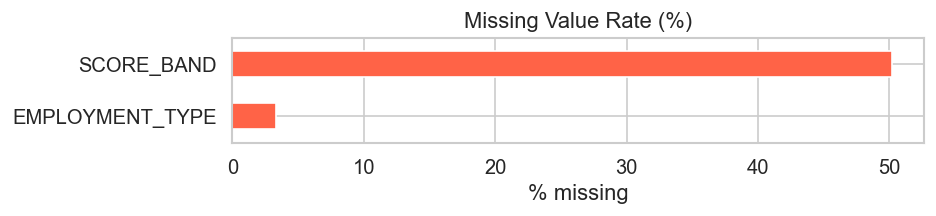


Duplicates: 0


In [23]:
# ============================================================
# 4. Missing Values
# ============================================================
miss = df.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)

if miss.empty:
    print("✅ No missing values")
else:
    miss_df = pd.DataFrame({
        "missing_count" : miss,
        "missing_%"     : (miss / len(df) * 100).round(2),
    })
    print("Missing Values:")
    display(miss_df)

    # visualise
    fig, ax = plt.subplots(figsize=(8, max(2, len(miss) * 0.5)))
    miss_df["missing_%"].sort_values().plot(kind="barh", ax=ax, color="tomato")
    ax.set_title("Missing Value Rate (%)")
    ax.set_xlabel("% missing")
    plt.tight_layout(); plt.show()

print(f"\nDuplicates: {df.duplicated().sum():,}")


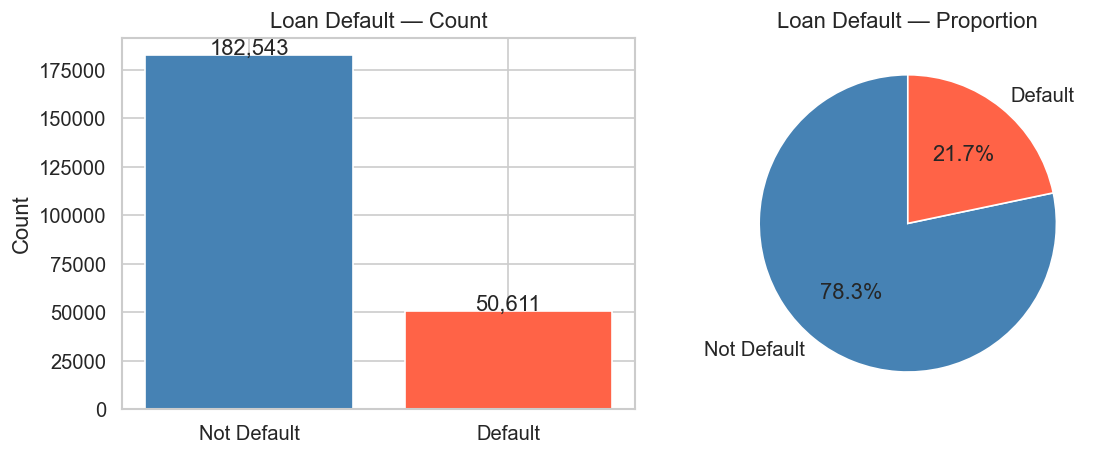

LOAN_DEFAULT
Not Default    182543
Default         50611


In [24]:
# ============================================================
# 5. Target Distribution
# ============================================================
vc = df["LOAN_DEFAULT"].value_counts().rename({0: "Not Default", 1: "Default"})
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(vc.index, vc.values, color=["steelblue", "tomato"])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 500, f"{v:,}", ha="center")
axes[0].set_title("Loan Default — Count")
axes[0].set_ylabel("Count")

axes[1].pie(vc.values, labels=vc.index, autopct="%1.1f%%",
            colors=["steelblue", "tomato"], startangle=90)
axes[1].set_title("Loan Default — Proportion")

plt.tight_layout(); plt.show()
print(vc.to_string())


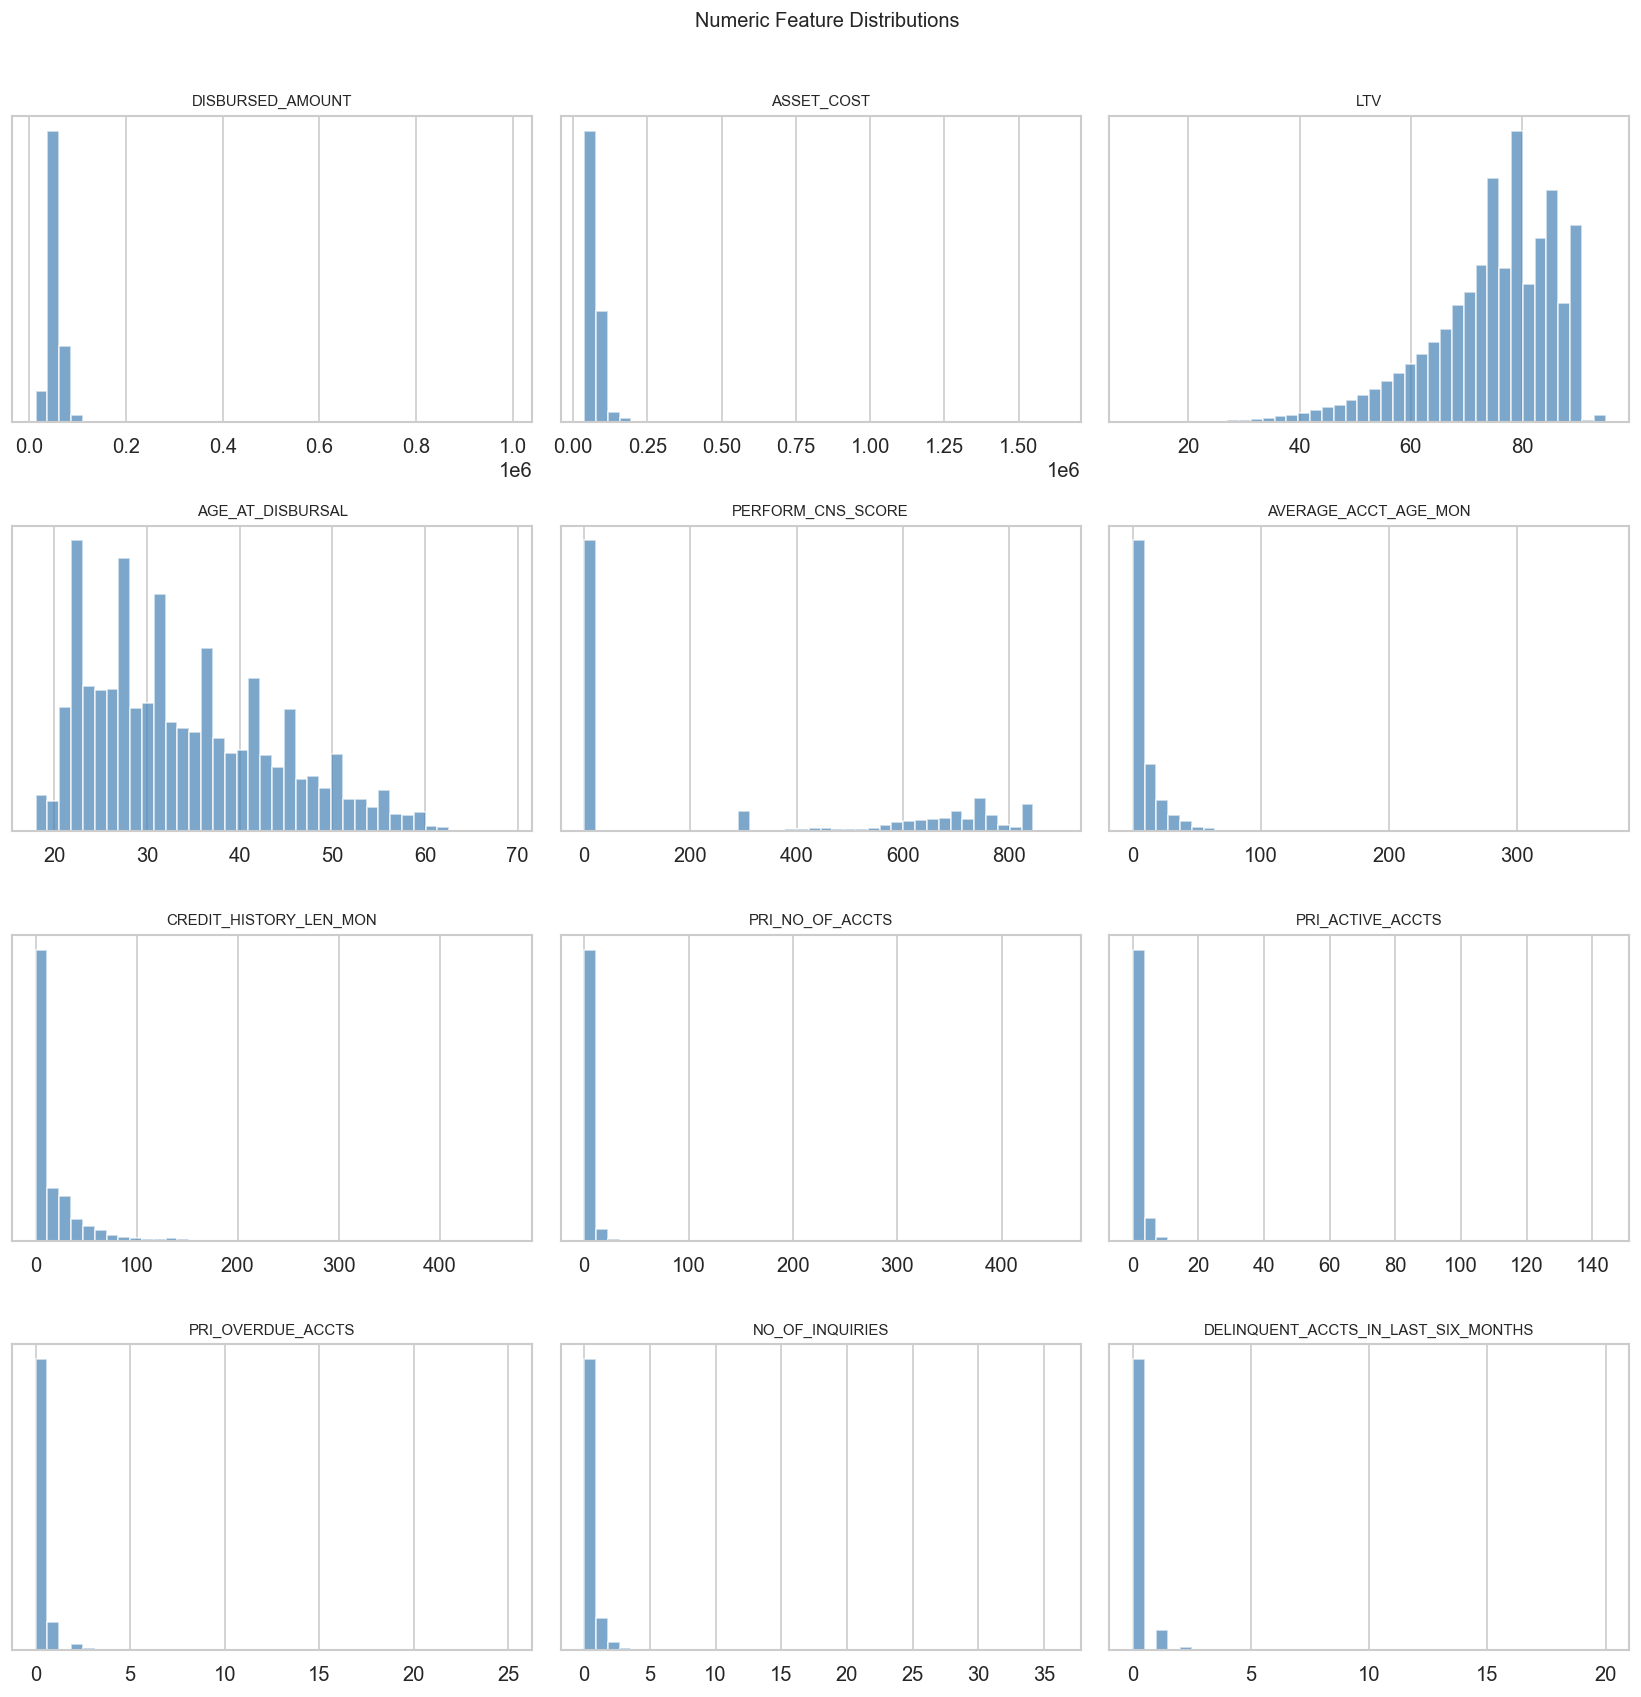

In [25]:
# ============================================================
# 6. Numeric Distributions (histograms + default-rate overlay)
# ============================================================
key_num = [
    "DISBURSED_AMOUNT", "ASSET_COST", "LTV",
    "AGE_AT_DISBURSAL", "PERFORM_CNS_SCORE",
    "AVERAGE_ACCT_AGE_MON", "CREDIT_HISTORY_LEN_MON",
    "PRI_NO_OF_ACCTS", "PRI_ACTIVE_ACCTS", "PRI_OVERDUE_ACCTS",
    "NO_OF_INQUIRIES", "DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS",
]

n_cols = 3
n_rows = -(-len(key_num) // n_cols)   # ceiling div
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(key_num):
    axes[i].hist(df[col].dropna(), bins=40, color="steelblue",
                 edgecolor="white", density=True, alpha=0.7)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_yticks([])

# hide unused
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions", y=1.01, fontsize=12)
plt.tight_layout(); plt.show()


In [26]:
# ============================================================
# 7. Categorical Summary
# ============================================================
cat_cols = ["EMPLOYMENT_TYPE", "PERFORM_CNS_SCORE_DESCRIPTION"]

for col in cat_cols:
    vc = df[col].value_counts(dropna=False)
    dr = df.groupby(col, dropna=False)["LOAN_DEFAULT"].mean().rename("default_rate")
    summary = pd.concat([vc.rename("count"), dr], axis=1)
    summary["count_%"] = (summary["count"] / len(df) * 100).round(1)
    print(f"\n── {col} ──")
    display(summary.sort_values("count", ascending=False))



── EMPLOYMENT_TYPE ──


,count,default_rate,count_%
EMPLOYMENT_TYPE,,,
Self employed,127635,0.227657,54.7
Salaried,97858,0.203458,42.0
NaN,7661,0.214593,3.3



── PERFORM_CNS_SCORE_DESCRIPTION ──


,count,default_rate,count_%
PERFORM_CNS_SCORE_DESCRIPTION,,,
No Bureau History Available,116950,0.231313,50.2
C-Very Low Risk,16045,0.172639,6.9
A-Very Low Risk,14124,0.165746,6.1
D-Very Low Risk,11358,0.149586,4.9
B-Very Low Risk,9201,0.131290,3.9
M-Very High Risk,8776,0.304581,3.8
F-Low Risk,8485,0.186211,3.6
K-High Risk,8277,0.278120,3.6
H-Medium Risk,6855,0.241867,2.9


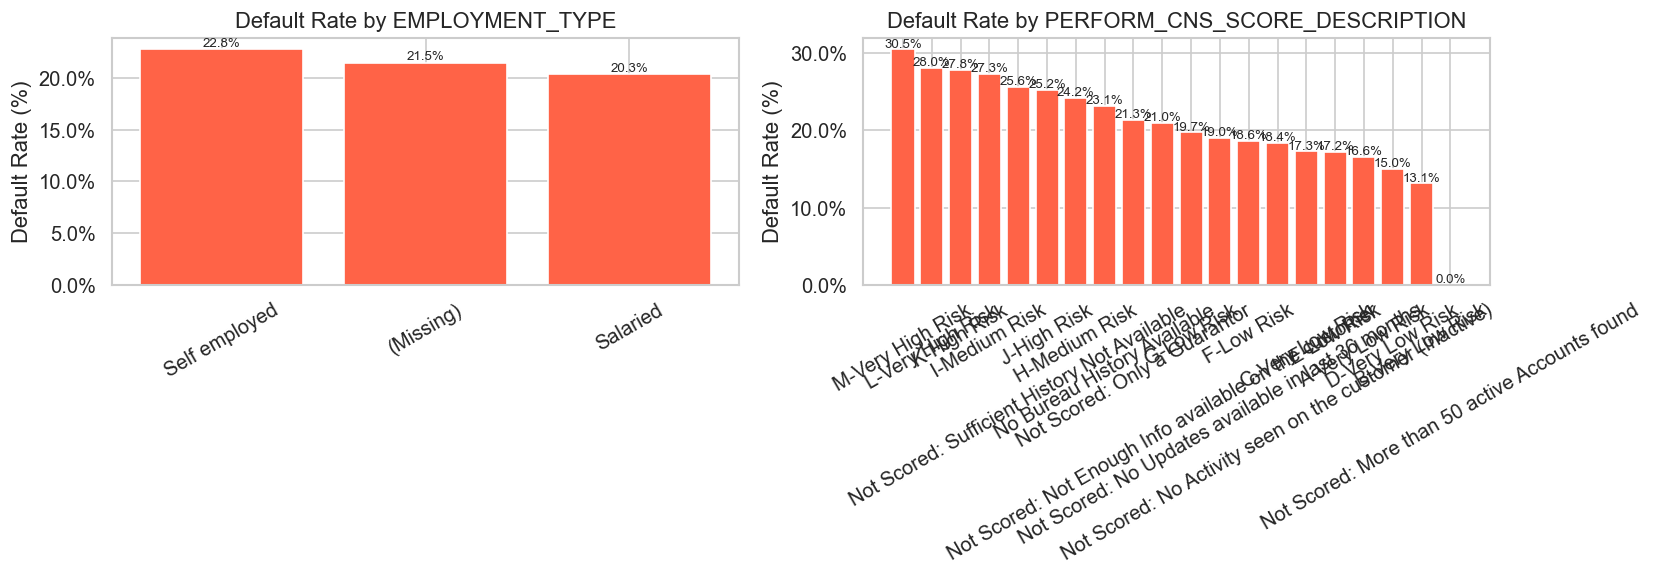

In [31]:
# ============================================================
# 8. Default Rate by Key Categorical Features (bar chart)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col in zip(axes, cat_cols):
    # fill NaN ก่อน groupby เพื่อป้องกัน float index
    dr = (df[col].fillna("(Missing)")
            .pipe(lambda s: df.assign(**{col: s}))
            .groupby(col)["LOAN_DEFAULT"].mean()
            .sort_values(ascending=False))
    
    ax.bar(dr.index.astype(str), dr.values * 100, color="tomato")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_title(f"Default Rate by {col}")
    ax.set_ylabel("Default Rate (%)")
    ax.tick_params(axis="x", rotation=30)
    for j, v in enumerate(dr.values):
        ax.text(j, v * 100 + 0.3, f"{v:.1%}", ha="center", fontsize=8)

plt.tight_layout(); plt.show()


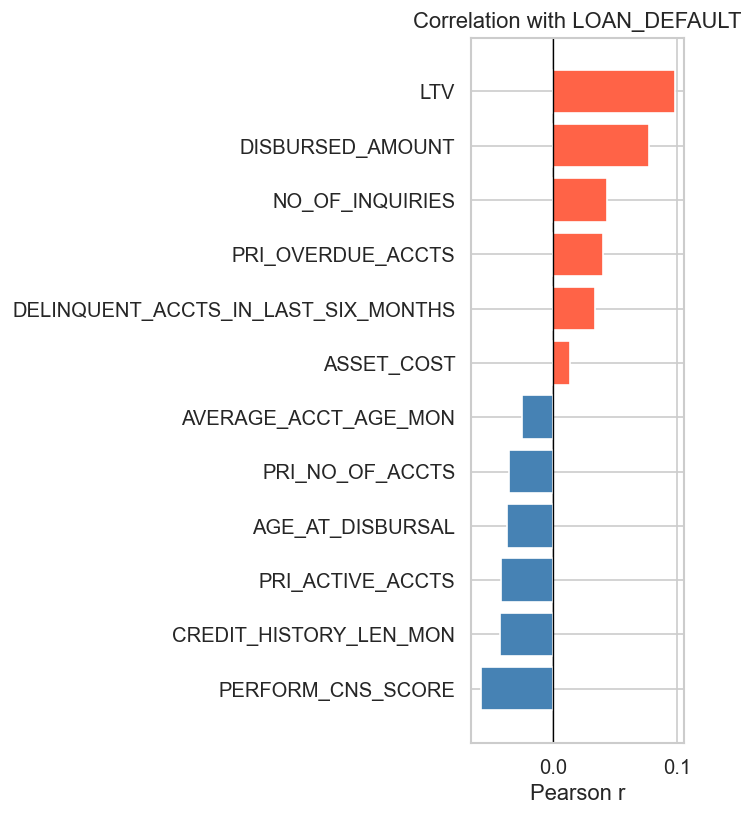

PERFORM_CNS_SCORE                     -0.057929
CREDIT_HISTORY_LEN_MON                -0.042126
PRI_ACTIVE_ACCTS                      -0.041451
AGE_AT_DISBURSAL                      -0.036549
PRI_NO_OF_ACCTS                       -0.035456
AVERAGE_ACCT_AGE_MON                  -0.024781
ASSET_COST                             0.014261
DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS    0.034462
PRI_OVERDUE_ACCTS                      0.040872
NO_OF_INQUIRIES                        0.043678
DISBURSED_AMOUNT                       0.077675
LTV                                    0.098208


In [30]:
# ============================================================
# 9. Correlation Heatmap (numeric cols vs target)
# ============================================================
corr_cols = key_num + ["LOAN_DEFAULT"]
corr = df[corr_cols].corr()["LOAN_DEFAULT"].drop("LOAN_DEFAULT").sort_values()

fig, ax = plt.subplots(figsize=(6, len(corr) * 0.5 + 1))
colors = ["tomato" if v > 0 else "steelblue" for v in corr.values]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlation with LOAN_DEFAULT")
ax.set_xlabel("Pearson r")
plt.tight_layout(); plt.show()
print(corr.to_string())


In [ ]:
df['']

0         0
1         1
2         0
3         0
4         0
         ..
233149    3
233150    0
233151    0
233152    0
233153    0
Name: TOTAL_ACTIVE_ACCTS, Length: 233154, dtype: int64

---
## 📊 Group 1 — Affordability (ความสามารถชำระหนี้)
> *ไม่มีข้อมูล income ใน dataset นี้ → ใช้ `LTV` และ bureau debt load เป็น proxy*

**สมมติฐาน:** LTV > 85% จะมี default rate สูงขึ้นชัดเจน

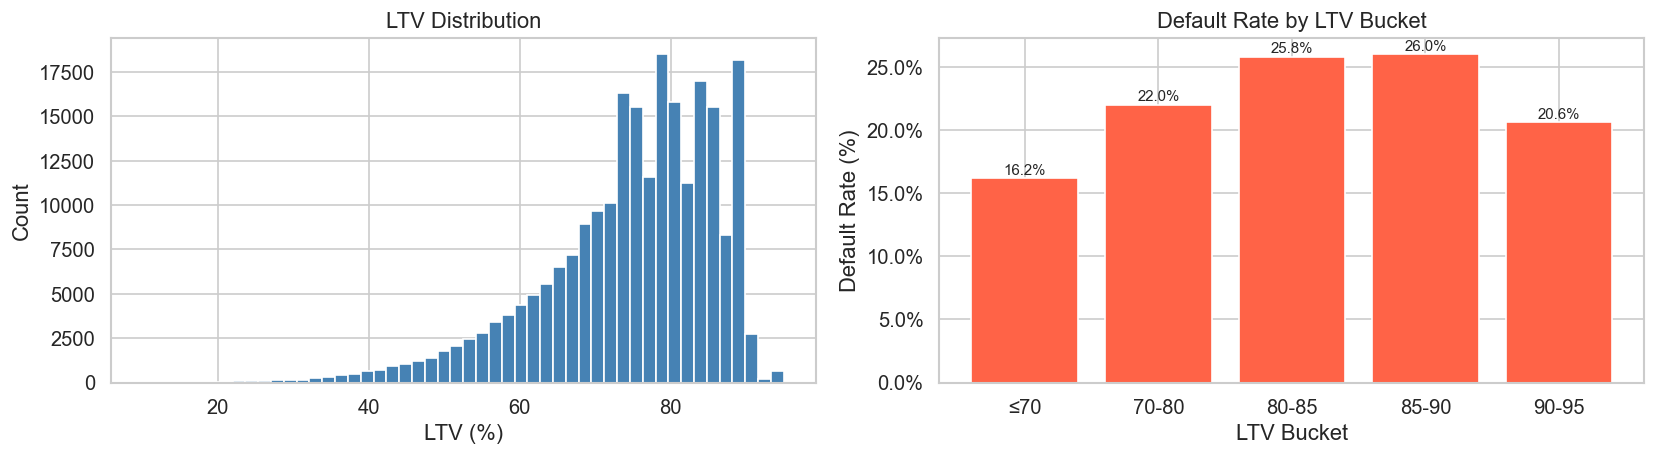

LTV_BIN  default_rate  count
    ≤70      0.161981  65662
  70-80      0.219931  85604
  80-85      0.257949  45982
  85-90      0.259972  35023
  90-95      0.206116    883


In [4]:
# Q1-A: LTV distribution + default rate by bucket
df["LTV_BIN"] = pd.cut(df["LTV"], bins=[0,70,80,85,90,95,100,200],
                        labels=["≤70","70-80","80-85","85-90","90-95","95-100",">100"])

ltv_dr = df.groupby("LTV_BIN", observed=True)["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
ltv_dr.columns = ["LTV_BIN","default_rate","count"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
# histogram
axes[0].hist(df["LTV"].dropna(), bins=50, color="steelblue", edgecolor="white")
axes[0].set(title="LTV Distribution", xlabel="LTV (%)", ylabel="Count")

# default rate by bucket
axes[1].bar(ltv_dr["LTV_BIN"].astype(str), ltv_dr["default_rate"]*100, color="tomato")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set(title="Default Rate by LTV Bucket", xlabel="LTV Bucket", ylabel="Default Rate (%)")
for i, row in ltv_dr.iterrows():
    axes[1].text(i, row["default_rate"]*100 + 0.3, f"{row['default_rate']:.1%}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()
print(ltv_dr.to_string(index=False))

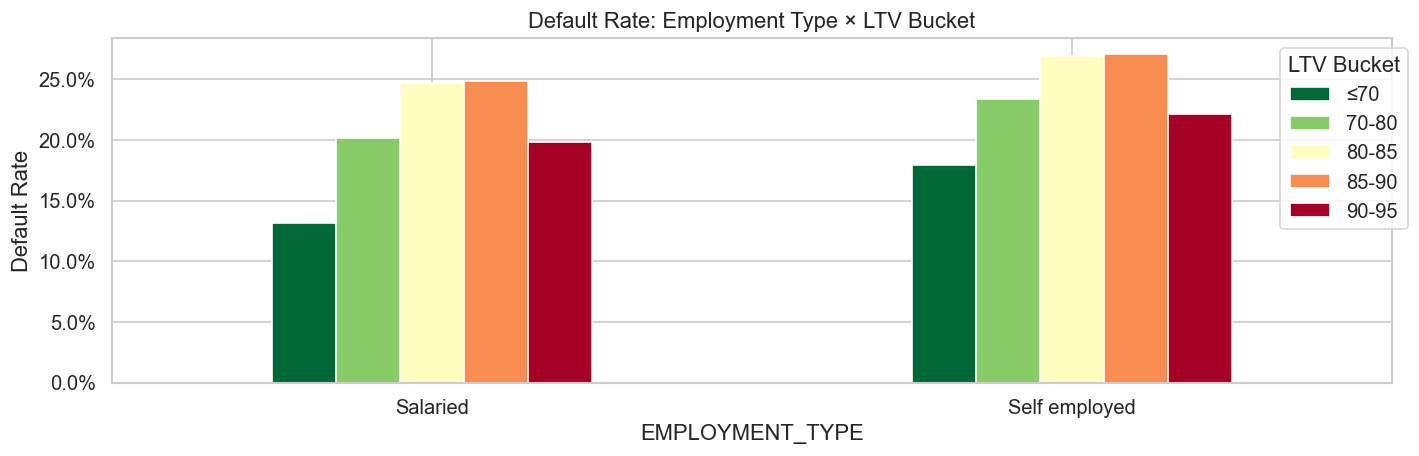

In [5]:
# Q1-B: Employment Type → LTV → Default Rate (3-way view)
emp_ltv = df.groupby(["EMPLOYMENT_TYPE","LTV_BIN"], observed=True)["LOAN_DEFAULT"].mean().unstack()
emp_ltv.plot(kind="bar", figsize=(12,4), colormap="RdYlGn_r")
plt.title("Default Rate: Employment Type × LTV Bucket")
plt.ylabel("Default Rate"); plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.legend(title="LTV Bucket", bbox_to_anchor=(1.02, 1))
plt.tight_layout(); plt.show()

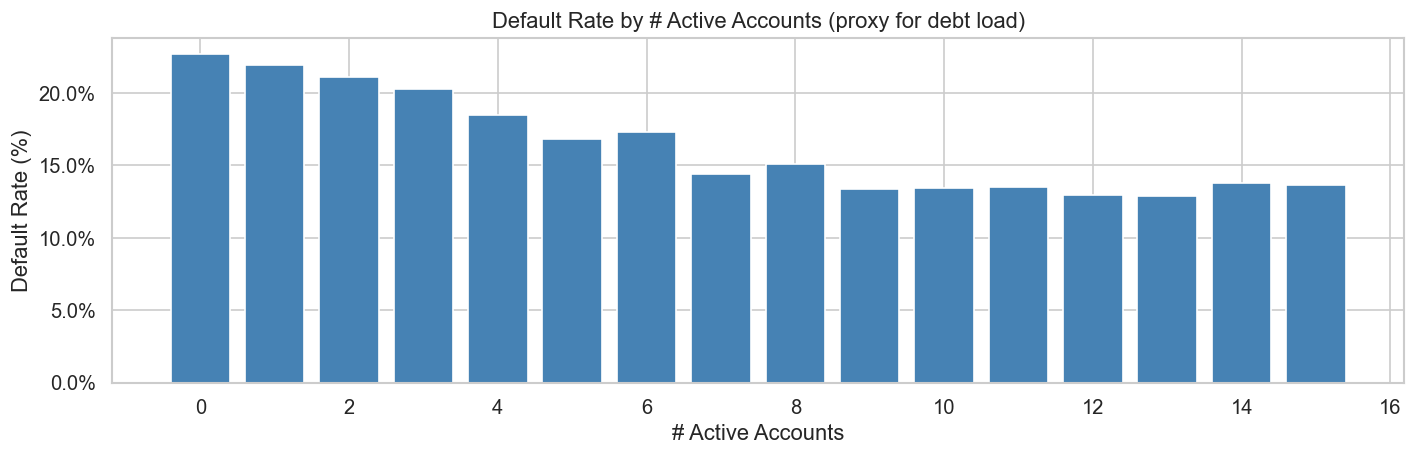

In [6]:
# Q1-C: Existing debt burden proxy
df["TOTAL_ACTIVE_ACCTS"] = df["PRI_ACTIVE_ACCTS"] + df["SEC_ACTIVE_ACCTS"]
debt_dr = df.groupby("TOTAL_ACTIVE_ACCTS")["LOAN_DEFAULT"].agg(["mean","count"])
debt_dr = debt_dr[debt_dr["count"] >= 100].reset_index()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(debt_dr["TOTAL_ACTIVE_ACCTS"], debt_dr["mean"]*100, color="steelblue")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Default Rate by # Active Accounts (proxy for debt load)",
       xlabel="# Active Accounts", ylabel="Default Rate (%)")
plt.tight_layout(); plt.show()

---
## 🚙 Group 2 — Collateral (คุณภาพหลักประกัน)
**สมมติฐาน:** ยี่ห้อรถราคาแพง (manufacturer_id ที่มี asset_cost สูง) จะมี default ต่ำ  
แต่คาดว่าเป็นเพราะลูกค้ากลุ่มนั้นรวยกว่า ไม่ใช่เพราะตัวรถ

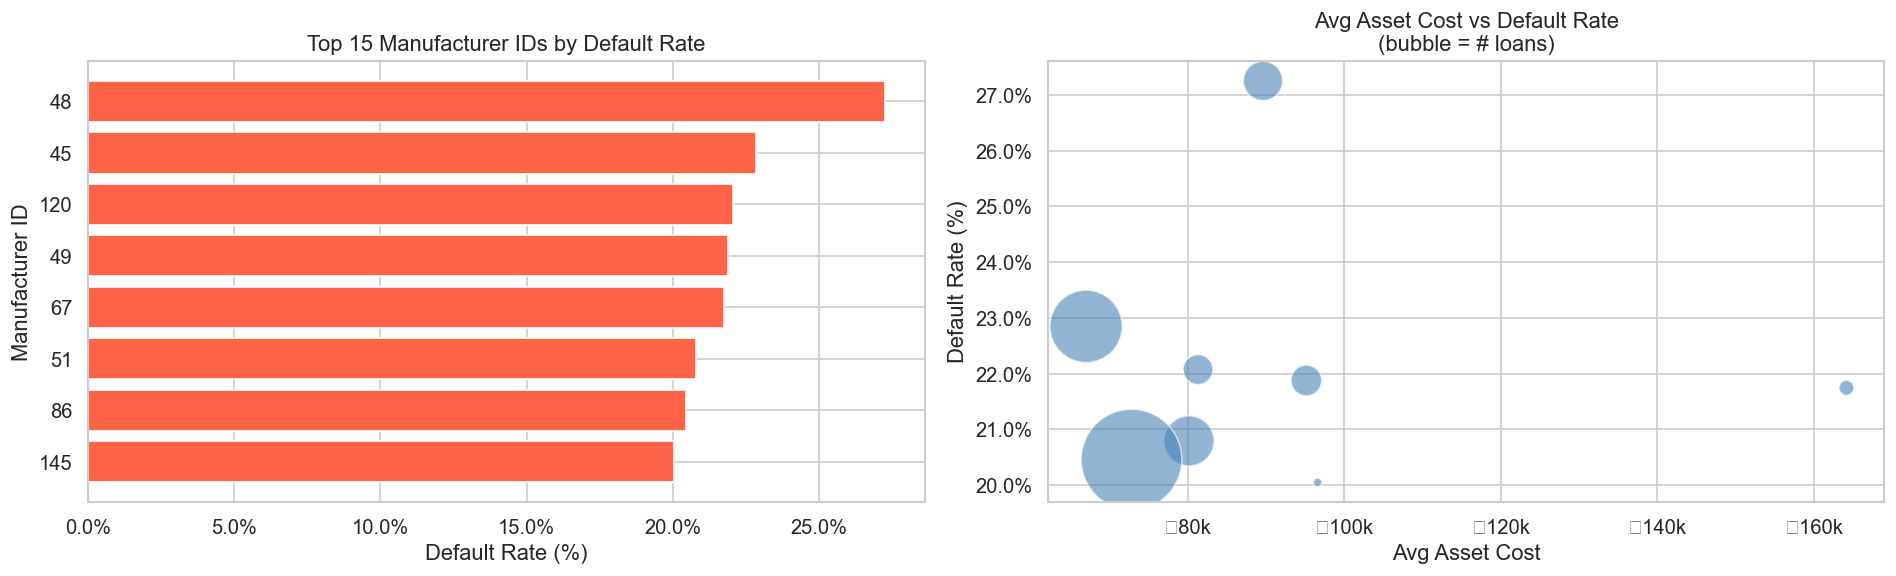

In [7]:
# Q2-A: manufacturer default rate + avg asset cost
mfr = df.groupby("MANUFACTURER_ID").agg(
    default_rate=("LOAN_DEFAULT","mean"),
    avg_cost=("ASSET_COST","mean"),
    count=("LOAN_DEFAULT","count")
).reset_index()
mfr = mfr[mfr["count"] >= 200].sort_values("default_rate", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
top_mfr = mfr.head(15)
axes[0].barh(top_mfr["MANUFACTURER_ID"].astype(str), top_mfr["default_rate"]*100, color="tomato")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter())
axes[0].set(title="Top 15 Manufacturer IDs by Default Rate", xlabel="Default Rate (%)", ylabel="Manufacturer ID")
axes[0].invert_yaxis()

axes[1].scatter(mfr["avg_cost"], mfr["default_rate"]*100, s=mfr["count"]/30,
                alpha=0.6, color="steelblue", edgecolors="white")
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f"₹{x/1000:.0f}k"))
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set(title="Avg Asset Cost vs Default Rate\n(bubble = # loans)",
            xlabel="Avg Asset Cost", ylabel="Default Rate (%)")
plt.tight_layout(); plt.show()

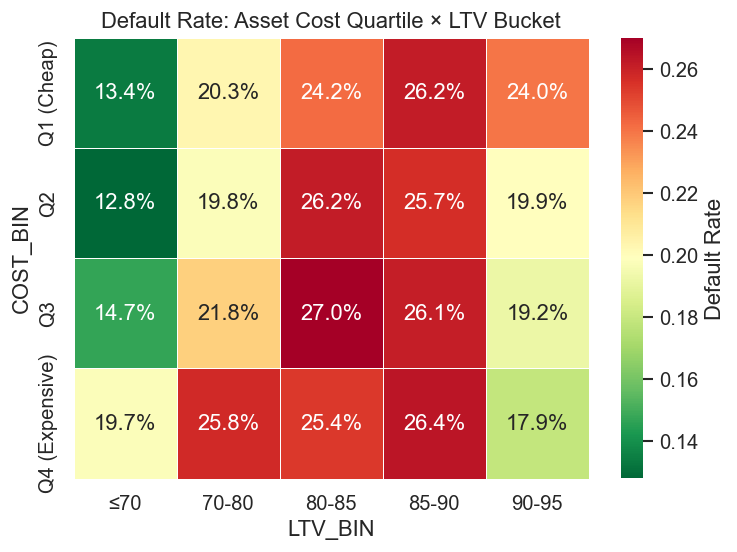

In [8]:
# Q2-B: LTV bucketed → asset cost bucket interaction
df["COST_BIN"] = pd.qcut(df["ASSET_COST"], q=4, labels=["Q1 (Cheap)","Q2","Q3","Q4 (Expensive)"])
pivot = df.groupby(["COST_BIN","LTV_BIN"], observed=True)["LOAN_DEFAULT"].mean().unstack()
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn_r", linewidths=0.5,
            cbar_kws={"label":"Default Rate"})
plt.title("Default Rate: Asset Cost Quartile × LTV Bucket")
plt.tight_layout(); plt.show()

---
## 💳 Group 3 — Credit Behavior (ประวัติพฤติกรรมเครดิต)
กลุ่มนี้ให้ predictive power สูงสุดใน dataset นี้  
**สมมติฐาน:** ลูกค้าที่ `PERFORM_CNS_SCORE = 0` (ไม่มีประวัติ) อาจเสี่ยงกว่าคนที่ score ต่ำด้วยซ้ำ

ลูกค้าที่ไม่มีประวัติเครดิต (score=0): 116,950 (50.2%)
Default rate ไม่มีประวัติ : 23.13%
Default rate มีประวัติ    : 20.27%


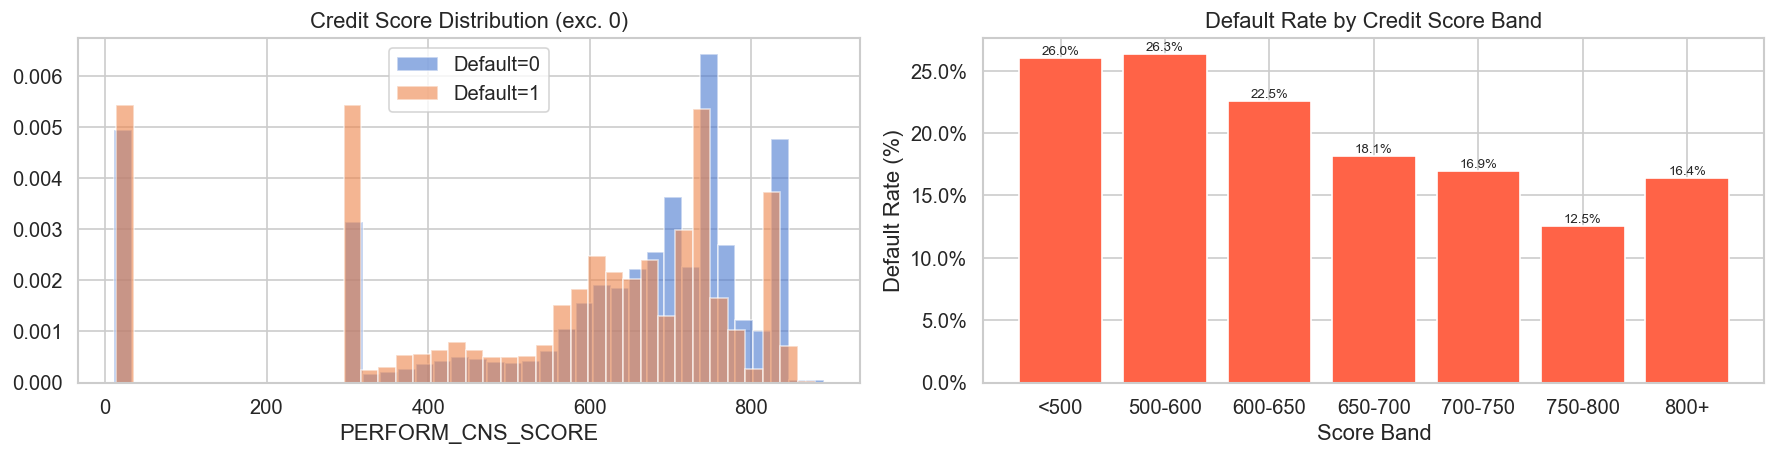

In [9]:
# Q3-A: Credit Score distribution by default
score_no_hist = df["PERFORM_CNS_SCORE"] == 0
print(f"ลูกค้าที่ไม่มีประวัติเครดิต (score=0): {score_no_hist.sum():,} ({score_no_hist.mean():.1%})")
print(f"Default rate ไม่มีประวัติ : {df[score_no_hist]['LOAN_DEFAULT'].mean():.2%}")
print(f"Default rate มีประวัติ    : {df[~score_no_hist]['LOAN_DEFAULT'].mean():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
# Distribution
for label, grp in df[~score_no_hist].groupby("LOAN_DEFAULT"):
    axes[0].hist(grp["PERFORM_CNS_SCORE"], bins=40, alpha=0.6,
                 label=f"Default={label}", density=True)
axes[0].set(title="Credit Score Distribution (exc. 0)", xlabel="PERFORM_CNS_SCORE")
axes[0].legend()

# Score band default rate
df["SCORE_BAND"] = pd.cut(df["PERFORM_CNS_SCORE"], bins=[0,1,500,600,650,700,750,800,900],
    labels=["No Hist","<500","500-600","600-650","650-700","700-750","750-800","800+"])
band_dr = df.groupby("SCORE_BAND", observed=True)["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
axes[1].bar(band_dr["SCORE_BAND"].astype(str), band_dr["mean"]*100, color="tomato")
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].set(title="Default Rate by Credit Score Band", xlabel="Score Band", ylabel="Default Rate (%)")
for i, row in band_dr.iterrows():
    axes[1].text(i, row["mean"]*100+0.3, f"{row['mean']:.1%}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

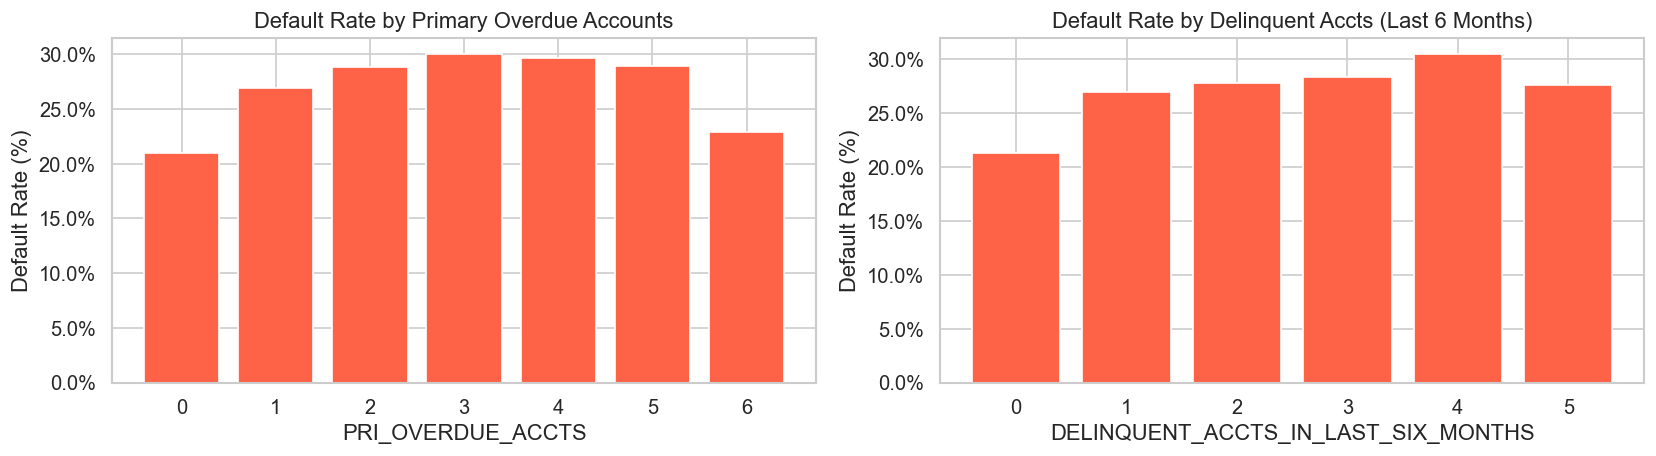

In [10]:
# Q3-B: Overdue accounts ทำนาย default ได้แค่ไหน
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes,
    ["PRI_OVERDUE_ACCTS","DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS"],
    ["Primary Overdue Accounts","Delinquent Accts (Last 6 Months)"]):
    tmp = df.groupby(col)["LOAN_DEFAULT"].agg(["mean","count"])
    tmp = tmp[tmp["count"] >= 50].reset_index()
    ax.bar(tmp[col], tmp["mean"]*100, color="tomato")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set(title=f"Default Rate by {title}", xlabel=col, ylabel="Default Rate (%)")
plt.tight_layout(); plt.show()


Default rate by secondary loan status:
                               Default Rate   Count
Primary Loans Only                 0.217527  229337
Has Secondary/Guarantor Loans      0.189678    3817


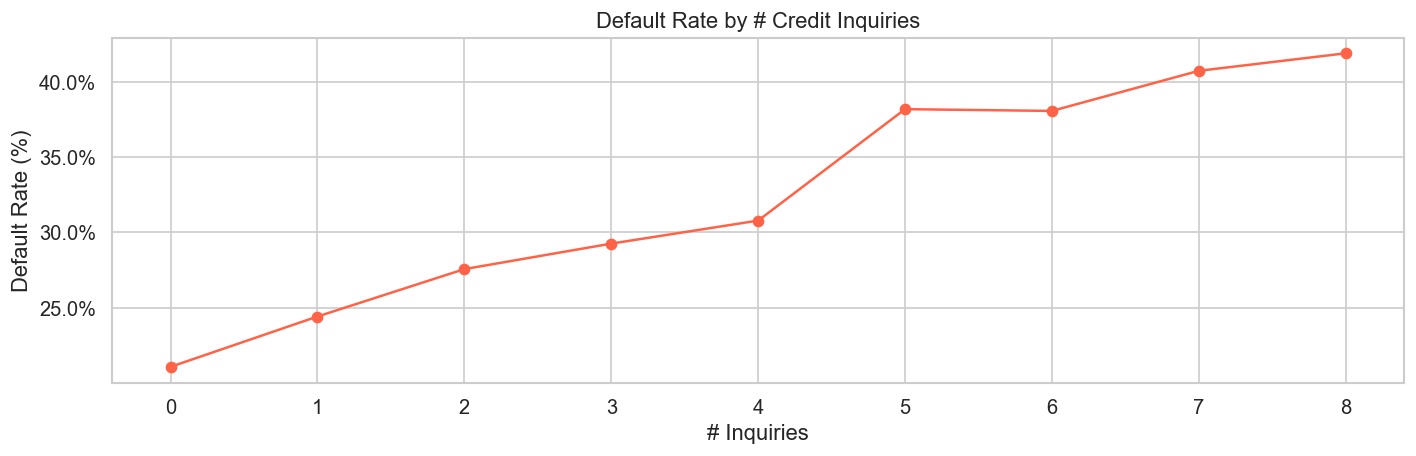

In [11]:
# Q3-C: Multiple active accounts → higher debt burden?
df["HAS_SEC_LOAN"] = (df["SEC_ACTIVE_ACCTS"] > 0).astype(int)
cross = df.groupby("HAS_SEC_LOAN")["LOAN_DEFAULT"].agg(["mean","count"])
cross.index = ["Primary Loans Only","Has Secondary/Guarantor Loans"]
print("\nDefault rate by secondary loan status:")
print(cross.rename(columns={"mean":"Default Rate","count":"Count"}).to_string())

# Q3-D: Inquiry count → default
inq = df.groupby("NO_OF_INQUIRIES")["LOAN_DEFAULT"].agg(["mean","count"])
inq = inq[inq["count"] >= 100].reset_index()
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(inq["NO_OF_INQUIRIES"], inq["mean"]*100, marker="o", color="tomato")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Default Rate by # Credit Inquiries", xlabel="# Inquiries", ylabel="Default Rate (%)")
plt.tight_layout(); plt.show()

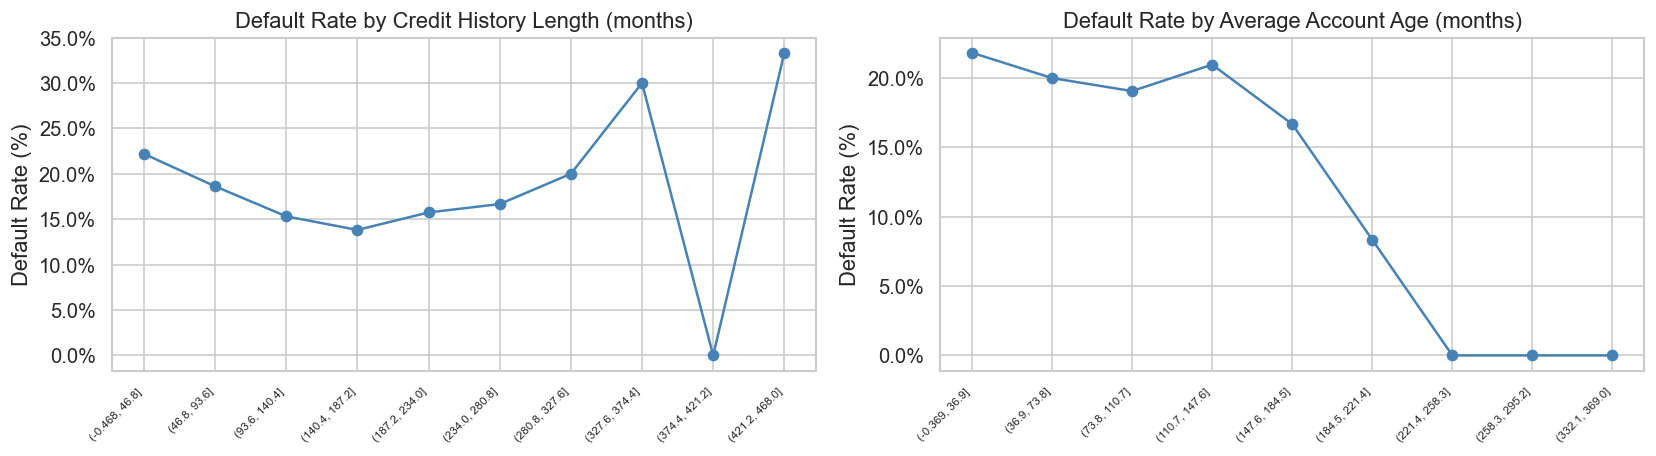

In [12]:
# Q3-E: Credit history length vs default
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes,
    ["CREDIT_HISTORY_LEN_MON","AVERAGE_ACCT_AGE_MON"],
    ["Credit History Length (months)","Average Account Age (months)"]):
    df["_tmp_bin"] = pd.cut(df[col], bins=10)
    tmp = df.groupby("_tmp_bin", observed=True)["LOAN_DEFAULT"].mean().reset_index()
    ax.plot(range(len(tmp)), tmp["LOAN_DEFAULT"]*100, marker="o", color="steelblue")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.set_xticks(range(len(tmp)))
    ax.set_xticklabels([str(x) for x in tmp["_tmp_bin"]], rotation=45, ha="right", fontsize=7)
    ax.set(title=f"Default Rate by {title}", ylabel="Default Rate (%)")
df.drop(columns=["_tmp_bin"], inplace=True)
plt.tight_layout(); plt.show()

---
## 📅 Group 4 — Temporal Patterns
**สมมติฐาน:** vintage บางปีมี default ผิดปกติ (external shock เช่น เศรษฐกิจ/โรคระบาด)

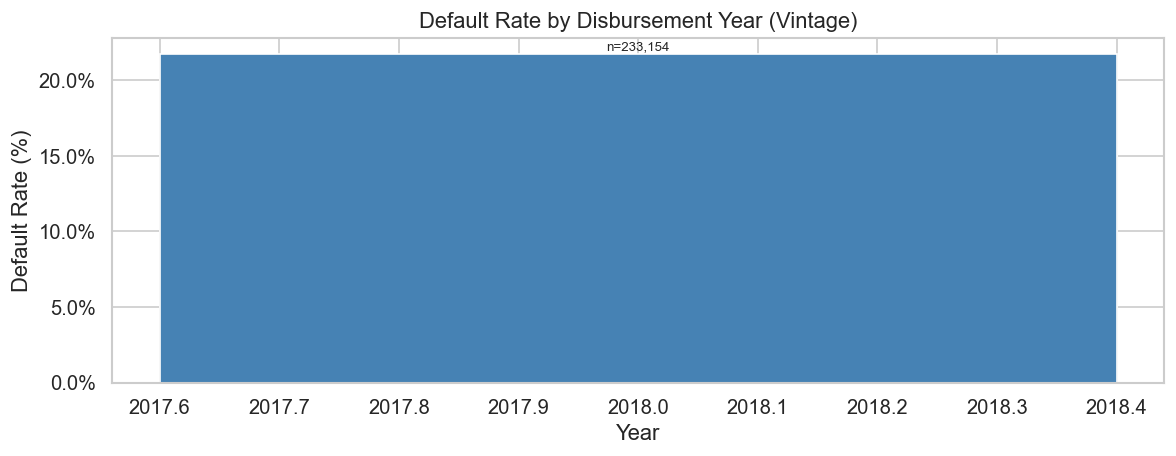

In [13]:
# Q4-A: Default rate by disbursement year (vintage)
df["DISBURSAL_YEAR"]  = df["DISBURSAL_DATE"].dt.year
df["DISBURSAL_MONTH"] = df["DISBURSAL_DATE"].dt.to_period("M").astype(str)

vintage = df.groupby("DISBURSAL_YEAR")["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(vintage["DISBURSAL_YEAR"], vintage["mean"]*100, color="steelblue")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Default Rate by Disbursement Year (Vintage)",
       xlabel="Year", ylabel="Default Rate (%)")
for bar, cnt in zip(bars, vintage["count"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"n={cnt:,}", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

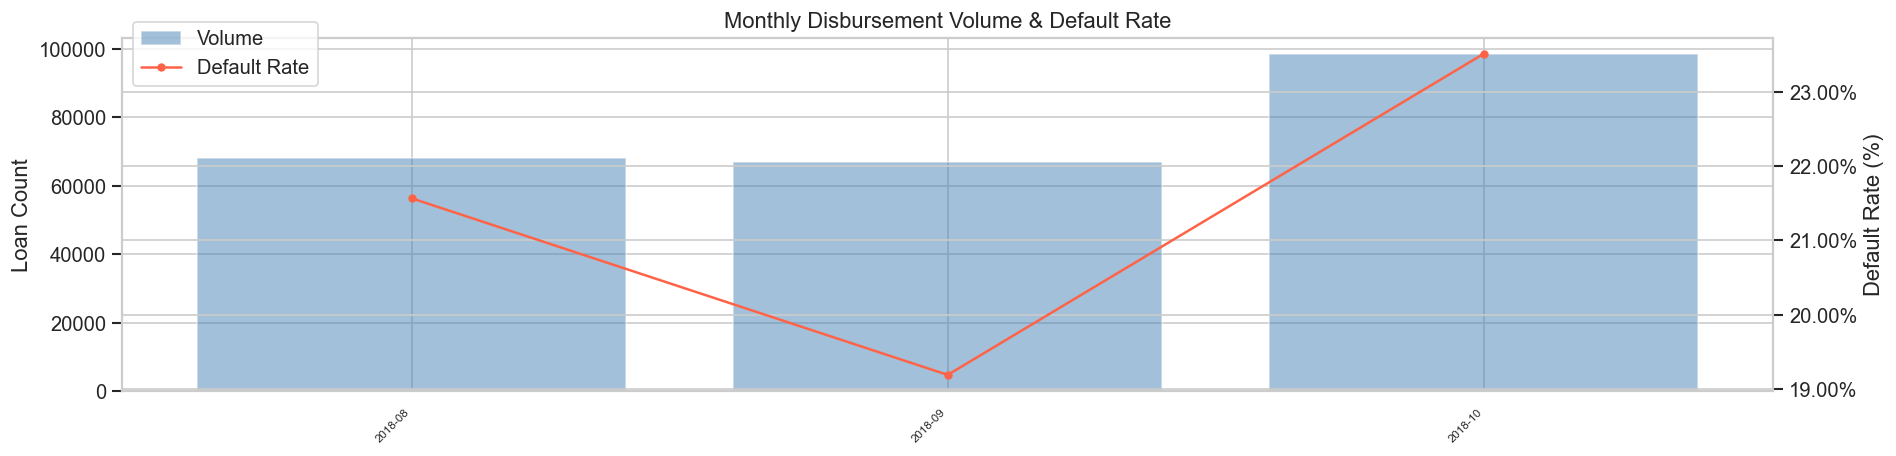

In [14]:
# Q4-B: Monthly volume + default rate trend
monthly = df.groupby("DISBURSAL_MONTH").agg(
    count=("LOAN_DEFAULT","count"),
    default_rate=("LOAN_DEFAULT","mean")
).reset_index().sort_values("DISBURSAL_MONTH")

fig, ax1 = plt.subplots(figsize=(16, 4))
ax2 = ax1.twinx()
ax1.bar(range(len(monthly)), monthly["count"], color="steelblue", alpha=0.5, label="Volume")
ax2.plot(range(len(monthly)), monthly["default_rate"]*100, color="tomato", marker="o", ms=4, label="Default Rate")
ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly["DISBURSAL_MONTH"], rotation=45, ha="right", fontsize=7)
ax1.set_ylabel("Loan Count"); ax2.set_ylabel("Default Rate (%)")
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_title("Monthly Disbursement Volume & Default Rate")
fig.legend(loc="upper left", bbox_to_anchor=(0.07, 0.95))
plt.tight_layout(); plt.show()

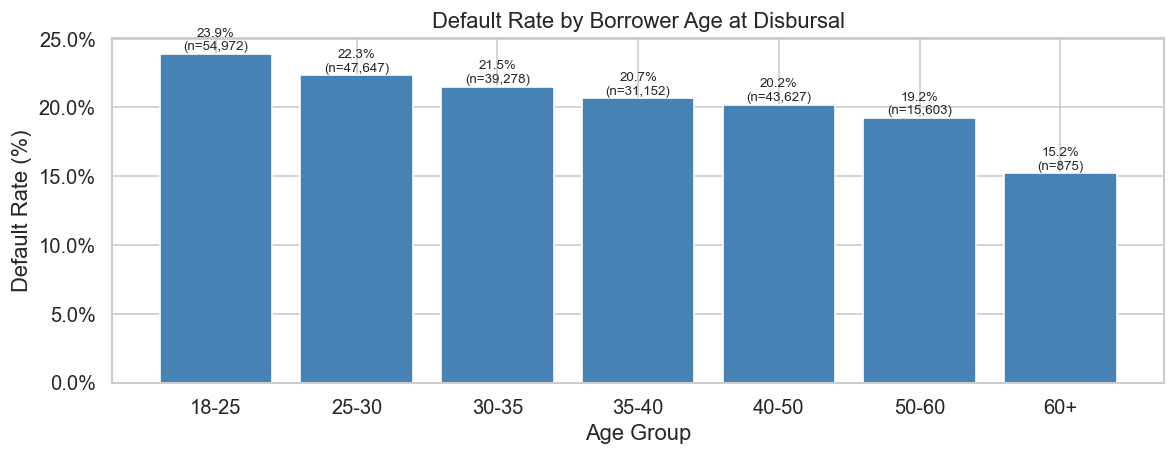

In [15]:
# Q4-C: Age of borrower at disbursal vs default
df["AGE_BIN"] = pd.cut(df["AGE_AT_DISBURSAL"], bins=[17,25,30,35,40,50,60,100],
                        labels=["18-25","25-30","30-35","35-40","40-50","50-60","60+"])
age_dr = df.groupby("AGE_BIN", observed=True)["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(age_dr["AGE_BIN"].astype(str), age_dr["mean"]*100, color="steelblue")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Default Rate by Borrower Age at Disbursal",
       xlabel="Age Group", ylabel="Default Rate (%)")
for i, row in age_dr.iterrows():
    ax.text(i, row["mean"]*100+0.3, f"{row['mean']:.1%}\n(n={row['count']:,})", ha="center", fontsize=8)
plt.tight_layout(); plt.show()

---
## 🔀 Group 5 — Segment Interactions
**สมมติฐาน:** Risk factors "คูณกัน" ไม่ใช่ "บวกกัน" — ลูกค้าที่มีหลาย risk factor พร้อมกัน จะ default สูงมากกว่าที่คาด


Interaction: LTV × Overdue Accounts
               label  Default Rate      N
 LTV≤85 + No Overdue      0.202601 175730
LTV≤85 + Has Overdue      0.265870  21518
 LTV>85 + No Overdue      0.250570  31149
LTV>85 + Has Overdue      0.311541   4757


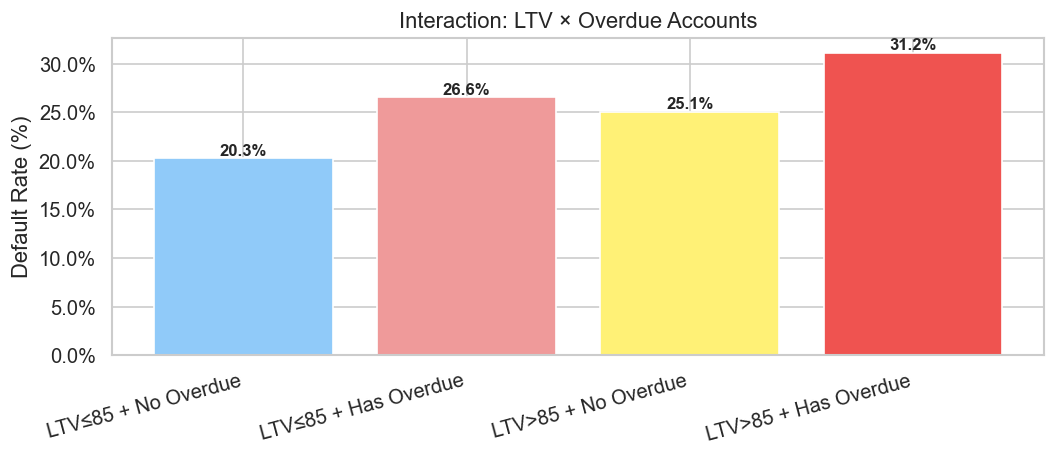

In [16]:
# Q5-A: LTV HIGH × Overdue accounts — do risks multiply?
df["LTV_HIGH"]     = (df["LTV"] > 85).astype(int)
df["HAS_OVERDUE"]  = (df["PRI_OVERDUE_ACCTS"] > 0).astype(int)

combo = df.groupby(["LTV_HIGH","HAS_OVERDUE"])["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
combo["label"] = combo.apply(
    lambda r: f"LTV{'≤' if r['LTV_HIGH']==0 else '>'}85 + {'No' if r['HAS_OVERDUE']==0 else 'Has'} Overdue", axis=1)
print("\nInteraction: LTV × Overdue Accounts")
print(combo[["label","mean","count"]].rename(columns={"mean":"Default Rate","count":"N"}).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#90CAF9","#EF9A9A","#FFF176","#EF5350"]
bars = ax.bar(combo["label"], combo["mean"]*100, color=colors)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Interaction: LTV × Overdue Accounts", ylabel="Default Rate (%)")
for bar, row in zip(bars, combo.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{row.mean:.1%}", ha="center", fontsize=10, fontweight="bold")
plt.xticks(rotation=15, ha="right"); plt.tight_layout(); plt.show()

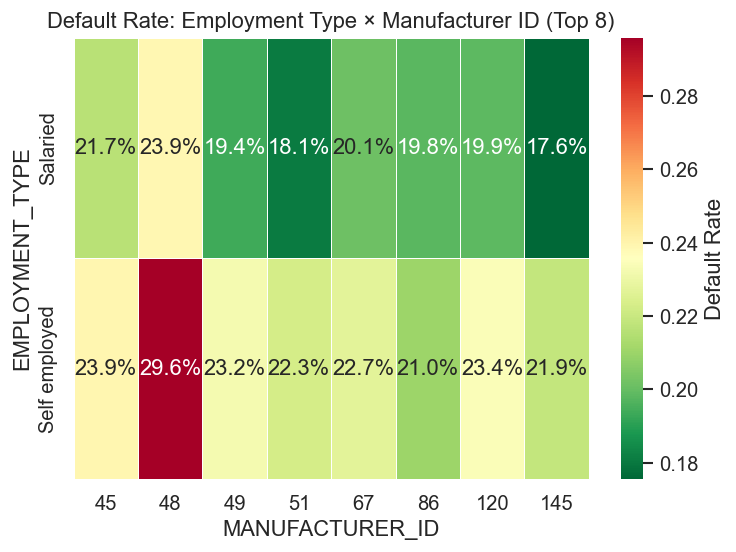

In [17]:
# Q5-B: Employment Type × Manufacturer → Profiling
# ถ้ายี่ห้อเดียวกัน แต่ประเภทอาชีพต่างกัน default rate ต่างกันไหม?
top_mfr_ids = df["MANUFACTURER_ID"].value_counts().head(8).index
sub = df[df["MANUFACTURER_ID"].isin(top_mfr_ids)]
pivot = sub.groupby(["EMPLOYMENT_TYPE","MANUFACTURER_ID"])["LOAN_DEFAULT"].mean().unstack()

sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn_r", linewidths=0.5,
            cbar_kws={"label":"Default Rate"})
plt.title("Default Rate: Employment Type × Manufacturer ID (Top 8)")
plt.tight_layout(); plt.show()

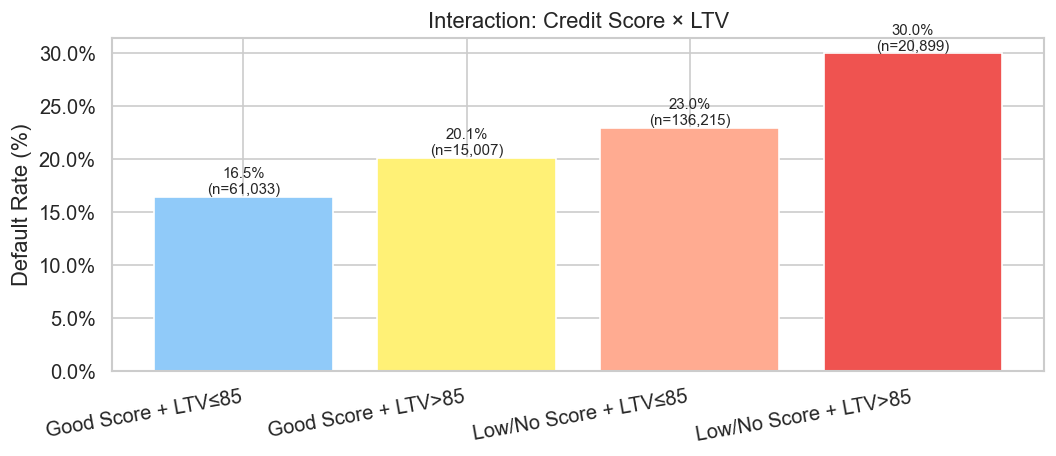

In [18]:
# Q5-C: Low CNS Score × High LTV → maximum risk segment?
df["LOW_SCORE"] = ((df["PERFORM_CNS_SCORE"] < 600) | (df["PERFORM_CNS_SCORE"] == 0)).astype(int)
risk_matrix = df.groupby(["LOW_SCORE","LTV_HIGH"])["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
risk_matrix["label"] = risk_matrix.apply(
    lambda r: f"{'Low/No Score' if r['LOW_SCORE']==1 else 'Good Score'} + LTV{'≤' if r['LTV_HIGH']==0 else '>'}85", axis=1)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ["#90CAF9","#FFF176","#FFAB91","#EF5350"]
bars = ax.bar(risk_matrix["label"], risk_matrix["mean"]*100, color=colors)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Interaction: Credit Score × LTV", ylabel="Default Rate (%)")
for bar, row in zip(bars, risk_matrix.itertuples()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{row.mean:.1%}\n(n={row.count:,})", ha="center", fontsize=9)
plt.xticks(rotation=10, ha="right"); plt.tight_layout(); plt.show()


Default Rate by Document Count:
 DOC_COUNT  Default Rate      N
         1      0.217228 213389
         2      0.216219  19434
         3      0.165138    327
         4      0.250000      4


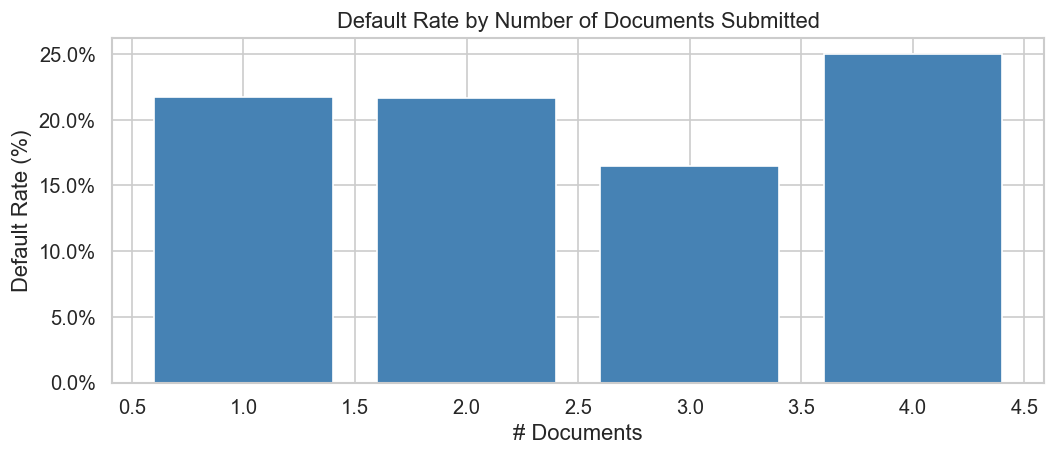

In [19]:
# Q5-D: Document completeness → risk signal?
doc_cols = ["AADHAR_FLAG","PAN_FLAG","VOTERID_FLAG","DRIVING_FLAG","PASSPORT_FLAG"]
df["DOC_COUNT"] = df[doc_cols].sum(axis=1)
doc_dr = df.groupby("DOC_COUNT")["LOAN_DEFAULT"].agg(["mean","count"]).reset_index()
print("\nDefault Rate by Document Count:")
print(doc_dr.rename(columns={"mean":"Default Rate","count":"N"}).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(doc_dr["DOC_COUNT"], doc_dr["mean"]*100, color="steelblue")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set(title="Default Rate by Number of Documents Submitted",
       xlabel="# Documents", ylabel="Default Rate (%)")
plt.tight_layout(); plt.show()

---
## 📝 Key Findings Summary

กรอกหลังรัน notebook ทั้งหมด:

| Theme | คำถาม | ผลที่ได้ | ตรงกับสมมติฐาน? | Feature candidates |
|---|---|---|---|---|
| Affordability | LTV > 85% → default สูง? | - | - | `LTV_HIGH`, `LTV_BIN` |
| Collateral | Manufacturer ID → default? | - | - | `MANUFACTURER_ID` |
| Credit Behavior | Score=0 vs Score ต่ำ | - | - | `SCORE_BAND`, `HAS_OVERDUE` |
| Temporal | Vintage year effect? | - | - | `DISBURSAL_YEAR` |
| Interaction | Low Score + High LTV = worst? | - | - | interaction features |

> **สิ่งที่ตรงข้ามกับสมมติฐาน (สำคัญที่สุด):** *กรอกที่นี่*